In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [5]:
from collections import deque

## Data Demostartion

In [20]:
df = pd.read_csv('Data/Raw_data/IM2606_20260514.csv', usecols=[0] + list(range(5, 25)))
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,bidSize1,bidSize2,bidSize3,bidSize4,bidSize5,askSize1,askSize2,askSize3,askSize4,askSize5
0,20260514 09:29:00.292932,8891.0,8890.4,8890.2,8890.0,8889.6,8891.4,8892.0,8893.0,8893.2,...,1.0,1.0,1.0,3.0,1.0,15.0,7.0,1.0,1.0,1.0
1,20260514 09:30:00.233226,8892.0,8891.6,8891.4,8891.2,8891.0,8898.0,8898.8,8899.0,8899.4,...,1.0,16.0,31.0,2.0,9.0,7.0,2.0,28.0,2.0,6.0
2,20260514 09:30:00.734494,8894.0,8893.8,8893.4,8893.2,8893.0,8895.4,8896.8,8897.2,8897.4,...,1.0,1.0,7.0,5.0,6.0,1.0,1.0,2.0,2.0,1.0
3,20260514 09:30:01.235377,8892.2,8892.0,8891.6,8891.4,8891.2,8893.2,8894.4,8896.6,8897.4,...,10.0,54.0,24.0,69.0,3.0,2.0,6.0,2.0,2.0,4.0
4,20260514 09:30:01.733066,8893.6,8893.2,8893.0,8892.0,8891.6,8895.4,8897.6,8898.0,8898.4,...,1.0,4.0,1.0,49.0,24.0,1.0,4.0,7.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28624,20260514 14:59:58.286068,8689.6,8689.4,8689.0,8688.8,8688.6,8689.8,8690.0,8690.4,8690.6,...,2.0,1.0,6.0,3.0,1.0,2.0,1.0,1.0,1.0,5.0
28625,20260514 14:59:58.783357,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,6.0,5.0,3.0,1.0,6.0,4.0,7.0,60.0,1.0,1.0
28626,20260514 14:59:59.282670,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,4.0,5.0,3.0,1.0,6.0,4.0,7.0,60.0,1.0,1.0
28627,20260514 14:59:59.784513,8689.8,8689.0,8688.8,8688.6,8688.2,8690.0,8690.8,8691.0,8691.2,...,3.0,5.0,3.0,1.0,6.0,1.0,3.0,7.0,60.0,1.0


In [21]:
df['MidPrice'] = (df['bid1'] + df['ask1']) / 2
df['MidPrice']

0        8891.2
1        8895.0
2        8894.7
3        8892.7
4        8894.5
          ...  
28624    8689.7
28625    8690.3
28626    8690.3
28627    8689.9
28628    8689.9
Name: MidPrice, Length: 28629, dtype: float64

In [25]:
for i in range(1,6):
    df[f'askcumSize{i}'] = df[f'askSize{i}'] + (df[f'askcumSize{i-1}'] if i != 1 else 0)
    df[f'bidcumSize{i}'] = df[f'bidSize{i}'] + (df[f'bidcumSize{i-1}'] if i != 1 else 0)
df.head()

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,askcumSize1,askcumSize2,askcumSize3,askcumSize4,askcumSize5,bidcumSize1,bidcumSize2,bidcumSize3,bidcumSize4,bidcumSize5
0,20260514 09:29:00.292932,8891.0,8890.4,8890.2,8890.0,8889.6,8891.4,8892.0,8893.0,8893.2,...,15.0,22.0,23.0,24.0,25.0,1.0,2.0,3.0,6.0,7.0
1,20260514 09:30:00.233226,8892.0,8891.6,8891.4,8891.2,8891.0,8898.0,8898.8,8899.0,8899.4,...,7.0,9.0,37.0,39.0,45.0,1.0,17.0,48.0,50.0,59.0
2,20260514 09:30:00.734494,8894.0,8893.8,8893.4,8893.2,8893.0,8895.4,8896.8,8897.2,8897.4,...,1.0,2.0,4.0,6.0,7.0,1.0,2.0,9.0,14.0,20.0
3,20260514 09:30:01.235377,8892.2,8892.0,8891.6,8891.4,8891.2,8893.2,8894.4,8896.6,8897.4,...,2.0,8.0,10.0,12.0,16.0,10.0,64.0,88.0,157.0,160.0
4,20260514 09:30:01.733066,8893.6,8893.2,8893.0,8892.0,8891.6,8895.4,8897.6,8898.0,8898.4,...,1.0,5.0,12.0,13.0,14.0,1.0,5.0,6.0,55.0,79.0


In [ ]:
def price_micro(df, level: int):
    price_cols = [f'bid{level}', f'ask{level}']
    size_cols = [f'bidcumSize{level}', f'askcumSize{level}']   
    df[f'price_micro_{level}'] = (df[price_cols[0]] * df[size_cols[1]] + df[price_cols[1]] * df[size_cols[0]]) / (df[size_cols[0]] + df[size_cols[1]])
    return None

In [12]:
for i in range(1,6):
    price_micro(df, level = i)
df

,timestamp,bid1,bid2,bid3,bid4,bid5,ask1,ask2,ask3,ask4,...,askSize2,askSize3,askSize4,askSize5,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5
0,20260514 09:29:00.292932,8891.0,8890.4,8890.2,8890.0,8889.6,8891.4,8892.0,8893.0,8893.2,...,7.0,1.0,1.0,1.0,8891.2,8891.025000,8890.600000,8891.600000,8892.400000,8891.800000
1,20260514 09:30:00.233226,8892.0,8891.6,8891.4,8891.2,8891.0,8898.0,8898.8,8899.0,8899.4,...,2.0,28.0,2.0,6.0,8895.0,8892.750000,8898.000000,8895.393220,8895.300000,8896.160000
2,20260514 09:30:00.734494,8894.0,8893.8,8893.4,8893.2,8893.0,8895.4,8896.8,8897.2,8897.4,...,1.0,2.0,2.0,1.0,8894.7,8894.700000,8895.300000,8896.355556,8896.200000,8897.285714
3,20260514 09:30:01.235377,8892.2,8892.0,8891.6,8891.4,8891.2,8893.2,8894.4,8896.6,8897.4,...,6.0,2.0,2.0,4.0,8892.7,8893.033333,8894.160000,8896.215385,8897.230986,8894.114286
4,20260514 09:30:01.733066,8893.6,8893.2,8893.0,8892.0,8891.6,8895.4,8897.6,8898.0,8898.4,...,4.0,7.0,1.0,1.0,8894.5,8894.500000,8895.400000,8893.625000,8898.272000,8898.320000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28624,20260514 14:59:58.286068,8689.6,8689.4,8689.0,8688.8,8688.6,8689.8,8690.0,8690.4,8690.6,...,1.0,1.0,1.0,5.0,8689.7,8689.700000,8689.700000,8690.200000,8690.150000,8688.966667
28625,20260514 14:59:58.783357,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,7.0,60.0,1.0,1.0,8690.3,8690.400000,8689.833333,8688.914286,8690.100000,8691.285714
28626,20260514 14:59:59.282670,8689.8,8689.0,8688.8,8688.6,8688.2,8690.8,8691.0,8691.2,8691.6,...,7.0,60.0,1.0,1.0,8690.3,8690.300000,8689.833333,8688.914286,8690.100000,8691.285714
28627,20260514 14:59:59.784513,8689.8,8689.0,8688.8,8688.6,8688.2,8690.0,8690.8,8691.0,8691.2,...,3.0,7.0,60.0,1.0,8689.9,8689.950000,8690.125000,8689.460000,8688.642623,8691.114286


In [13]:
df_selected = pd.concat([df.iloc[:, [0]], df.iloc[:, -6:]], axis=1)
m_plus_t = df_selected['MidPrice'].rolling(window=10).mean().shift(-10)
df_selected['price_move_smooth'] = m_plus_t - df_selected['MidPrice']
df_selected['price_move'] = (df_selected['MidPrice'].shift(-10) - df_selected['MidPrice'])
df_selected['price_move_smooth_pctg'] = df_selected['price_move_smooth'] / df_selected['MidPrice']
df_selected['price_move_pctg'] = df_selected['price_move'] / df_selected['MidPrice']
df_selected

,timestamp,MidPrice,price_micro_1,price_micro_2,price_micro_3,price_micro_4,price_micro_5,price_move_smooth,price_move,price_move_smooth_pctg,price_move_pctg
0,20260514 09:29:00.292932,8891.2,8891.025000,8890.600000,8891.600000,8892.400000,8891.800000,0.40,-5.3,0.000045,-0.000596
1,20260514 09:30:00.233226,8895.0,8892.750000,8898.000000,8895.393220,8895.300000,8896.160000,-4.62,-12.2,-0.000519,-0.001372
2,20260514 09:30:00.734494,8894.7,8894.700000,8895.300000,8896.355556,8896.200000,8897.285714,-5.64,-13.2,-0.000634,-0.001484
3,20260514 09:30:01.235377,8892.7,8893.033333,8894.160000,8896.215385,8897.230986,8894.114286,-4.80,-11.6,-0.000540,-0.001304
4,20260514 09:30:01.733066,8894.5,8894.500000,8895.400000,8893.625000,8898.272000,8898.320000,-7.74,-11.4,-0.000870,-0.001282
...,...,...,...,...,...,...,...,...,...,...,...
28624,20260514 14:59:58.286068,8689.7,8689.700000,8689.700000,8690.200000,8690.150000,8688.966667,NaN,NaN,NaN,NaN
28625,20260514 14:59:58.783357,8690.3,8690.400000,8689.833333,8688.914286,8690.100000,8691.285714,NaN,NaN,NaN,NaN
28626,20260514 14:59:59.282670,8690.3,8690.300000,8689.833333,8688.914286,8690.100000,8691.285714,NaN,NaN,NaN,NaN
28627,20260514 14:59:59.784513,8689.9,8689.950000,8690.125000,8689.460000,8688.642623,8691.114286,NaN,NaN,NaN,NaN


upper bond: 0.01000000%, lower bond: -0.01000000%


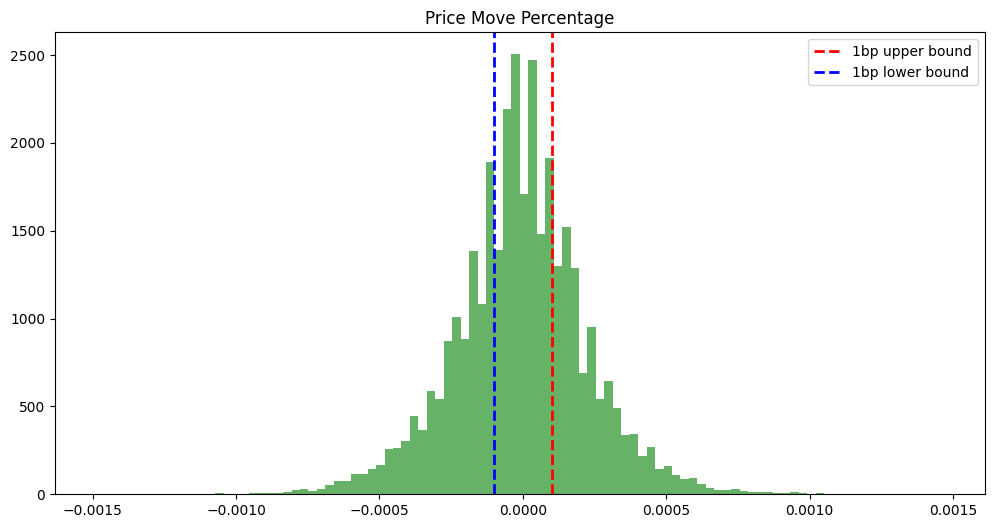

In [ ]:
# Calculate percentiles
p_upper = 0.0001
p_lower = -0.0001
print(f"upper bond: {p_upper*100:0.8f}%, lower bond: {p_lower*100:0.8f}%")
plt.figure(figsize=(12, 6))
plt.hist(df_selected['price_move_pctg'], bins=100, density=True, alpha=0.6, color='g')
plt.axvline(x=p_upper, color='r', linestyle='--', linewidth=2, label=f'1bp upper bound')
plt.axvline(x=p_lower, color='b', linestyle='--', linewidth=2, label=f'1bp lower bound')
plt.title('Price Move Percentage')
plt.legend()
plt.show()

upper bond: 0.01%, lower bond: -0.01%


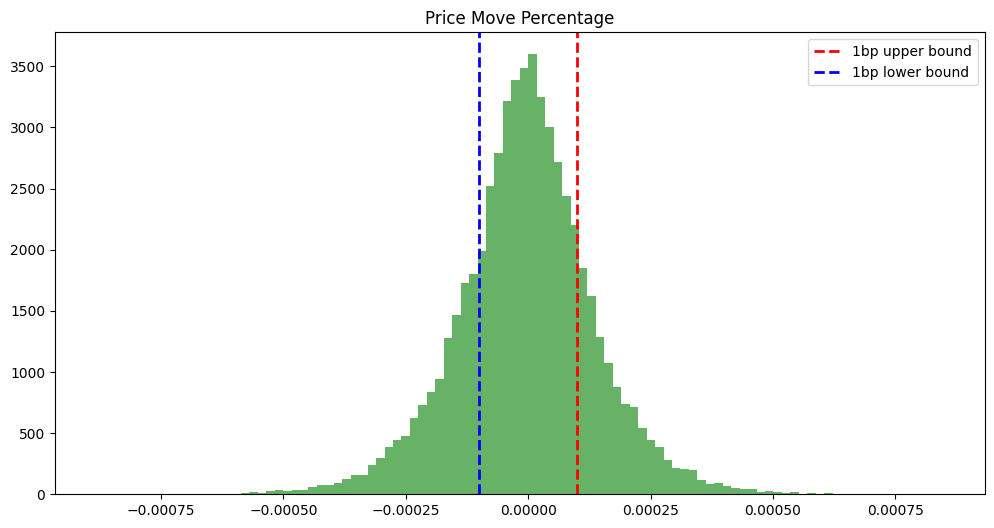

In [30]:
# Calculate percentiles
p_upper = 0.0001
p_lower = -0.0001
print(f"upper bond: {p_upper*100}%, lower bond: {p_lower*100}%")
plt.figure(figsize=(12, 6))
plt.hist(df_selected['price_move_smooth_pctg'], bins=100, density=True, alpha=0.6, color='g')
plt.axvline(x=p_upper, color='r', linestyle='--', linewidth=2, label=f'1bp upper bound')
plt.axvline(x=p_lower, color='b', linestyle='--', linewidth=2, label=f'1bp lower bound')
plt.title('Price Move Percentage')
plt.legend()
plt.show()

In [15]:
def move_label(x, alpha = 0.0002):
    if x > alpha:
        return 1
    elif x < -alpha:
        return -1
    else:
        return 0

In [20]:
alpha = 0.0001
df_selected['price_move_label'] = df_selected['price_move_pctg'].apply(lambda x: move_label(x, alpha))
df_selected['price_move_label'].value_counts(normalize=True)

price_move_label
 0    0.385483
-1    0.318349
 1    0.296168
Name: proportion, dtype: float64

In [17]:
df_selected['price_move_label'].value_counts().values

array([16053,  6540,  6140])

In [29]:
from pathlib import Path
base_path = Path('Data/Normalized_data')
csv_files = sorted(base_path.glob('normalized_*.csv'))
print(f"Found {len(csv_files)} CSV files to merge.")

def load_and_transform(file):
    df = pd.read_csv(file)
    # 你的逻辑：标签 + 1
    df['price_move_label'] = df['price_move_label'] + 1
    return df

data_frames = [load_and_transform(f) for f in csv_files]

big_df = pd.concat(data_frames, ignore_index=True)
big_df.info()

Found 10 CSV files to merge.
<class 'pandas.DataFrame'>
RangeIndex: 284180 entries, 0 to 284179
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   price_micro_1     284180 non-null  float64
 1   price_micro_2     284180 non-null  float64
 2   price_micro_3     284180 non-null  float64
 3   price_micro_4     284180 non-null  float64
 4   price_micro_5     284180 non-null  float64
 5   price_move_label  284180 non-null  int64  
dtypes: float64(5), int64(1)
memory usage: 13.0 MB


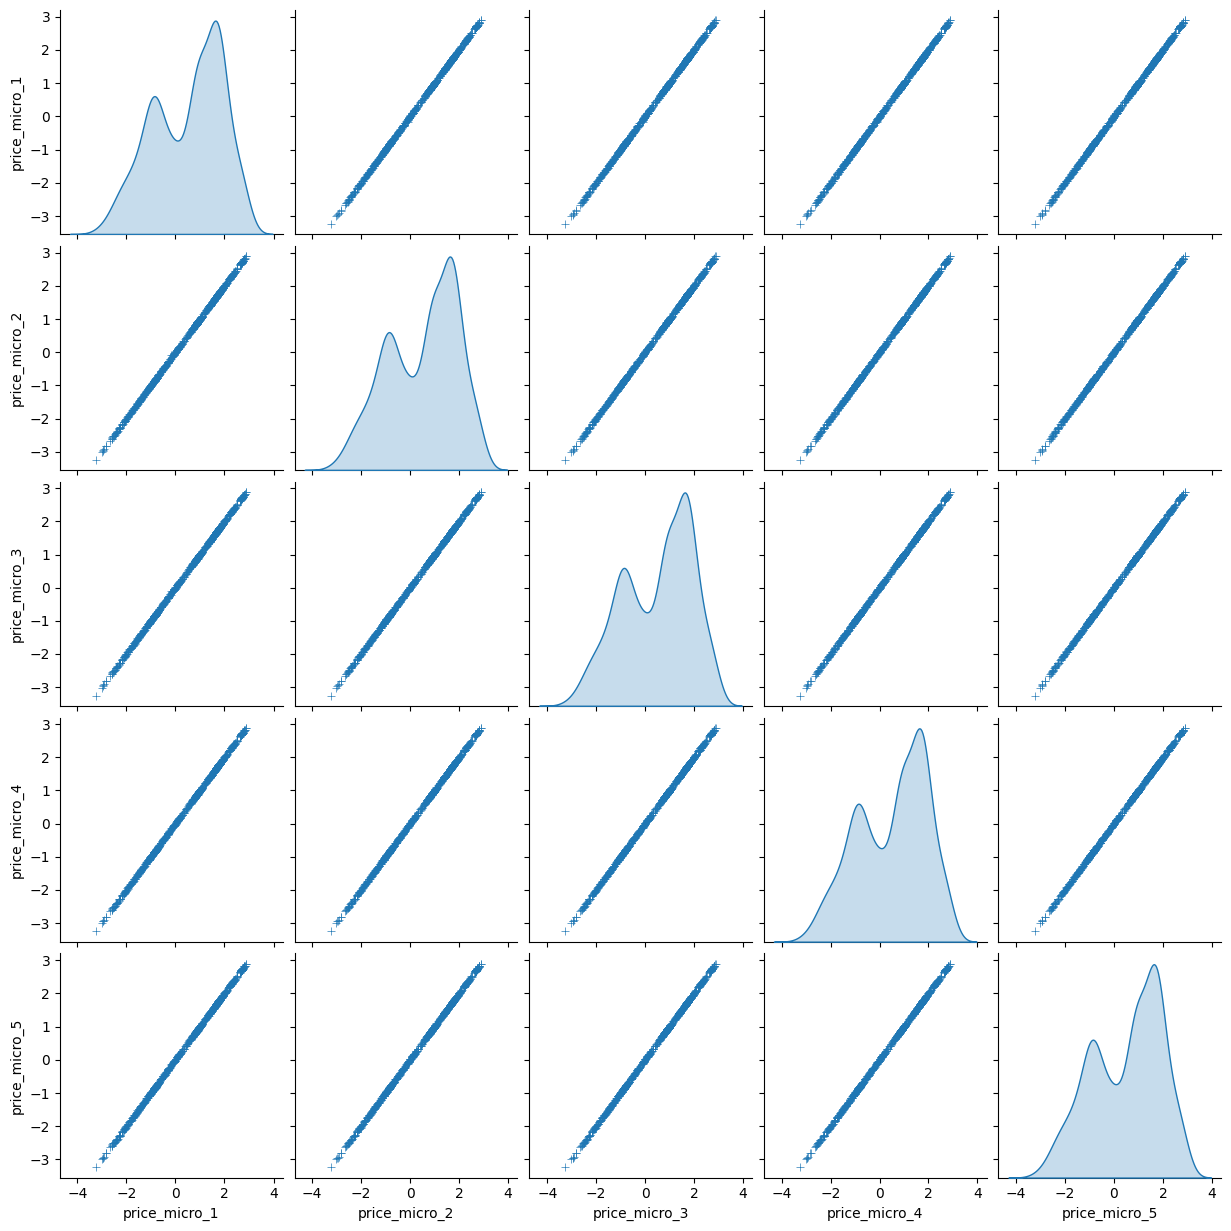

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

feature_cols = [col for col in big_df.columns if col.startswith('price_micro')] 
df_subset = big_df[feature_cols].sample(n=1000, random_state=42)

# 2. 绘制 Pair Scatter
# hue 参数可以指定按类别上色，如果你有分类标签的话
sns.pairplot(df_subset, diag_kind='kde', markers='+')

奇异值 (Singular Values): [1.82922305e+03 3.60430400e+00 1.85642339e+00 1.35553463e+00
 1.10567301e+00]


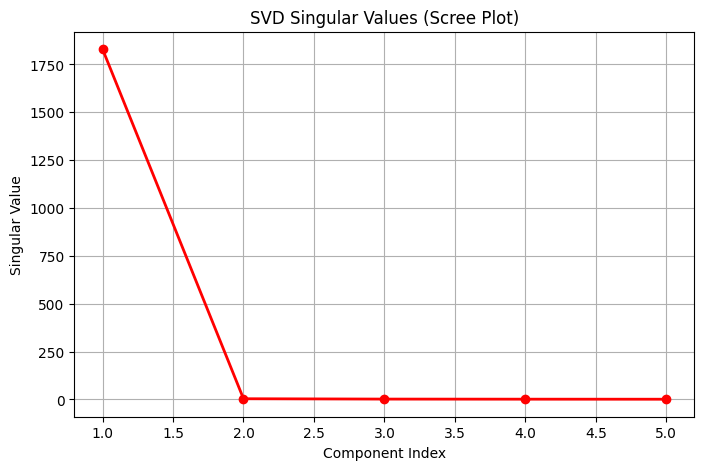

In [31]:
features = big_df[feature_cols].values

# SVD
U, S, Vt = np.linalg.svd(features, full_matrices=False)

# 3. 打印奇异值
print("奇异值 (Singular Values):", S)

# 4. 绘制“陡坡图” (Scree Plot)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(S) + 1), S, 'o-', linewidth=2, color='r')
plt.title('SVD Singular Values (Scree Plot)')
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.grid(True)
plt.show()

## CNN Structure

In [1]:
from DeepLOB import create_dataloader, DeepLOB, train_model, validate_engine

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

In [6]:
data = pd.read_csv('Data/Normalized_data/normalized_0515.csv')
data

,ask1,askSize1,bid1,bidSize1,ask2,askSize2,bid2,bidSize2,ask3,askSize3,...,bidSize3,ask4,askSize4,bid4,bidSize4,ask5,askSize5,bid5,bidSize5,price_move_label
0,-0.165522,-0.411122,-0.168163,0.513448,-0.159296,0.695718,-0.165103,-0.025467,-0.158511,0.216869,...,-0.280304,-0.160721,-0.234009,-0.228926,0.336425,-0.156707,-0.354578,-0.226789,-0.469237,1
1,-0.177935,-0.411122,-0.168163,0.996063,-0.078615,-0.205651,-0.165103,0.908388,-0.074728,-0.358871,...,-0.280304,-0.076940,0.517476,-0.228926,0.336425,-0.079133,0.034815,-0.226789,-0.469237,1
2,-0.081735,1.532930,-0.149546,-0.451782,-0.063100,-0.055423,-0.146485,-0.492394,-0.059212,-0.214936,...,4.447524,-0.061424,-0.384306,-0.151340,3.600723,-0.063619,-0.354578,-0.149194,1.078586,1
3,-0.131386,-0.411122,-0.143341,-0.451782,-0.112749,-0.355879,-0.140279,6.278055,-0.115068,-0.358871,...,-0.055169,-0.117279,-0.384306,-0.135822,0.336425,-0.116369,-0.354578,-0.139883,6.495965,1
4,-0.078632,-0.411122,-0.068875,-0.451782,-0.063100,0.695718,-0.090631,-0.492394,-0.059212,-0.214936,...,-0.505438,-0.061424,-0.384306,-0.098581,0.132406,-0.063619,-0.354578,-0.096430,0.885108,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28718,-2.198127,-0.411122,-2.194267,1.719985,-2.188709,0.395261,-2.191362,4.643808,-2.184825,-0.358871,...,-0.505438,-2.183893,-0.384306,-2.193403,-0.071613,-2.179836,-0.094983,-2.194596,-0.469237,1
28719,-2.173301,-0.411122,-2.181856,-0.210474,-2.173194,-0.355879,-2.185156,-0.258930,-2.169309,-0.071001,...,1.520774,-2.162172,-0.384306,-2.180989,3.804742,-2.164321,-0.354578,-2.179077,-0.469237,1
28720,-2.157785,-0.216716,-2.153931,-0.451782,-2.151472,-0.355879,-2.163435,-0.492394,-2.147588,-0.358871,...,-0.055169,-2.137347,-0.234009,-2.168576,-0.479650,-2.139497,-0.354578,-2.169766,-0.275759,1
28721,-2.136063,-0.411122,-2.144622,-0.451782,-2.126647,-0.205651,-2.144817,-0.492394,-2.128969,-0.358871,...,-0.505438,-2.121832,-0.384306,-2.165472,-0.479650,-2.117777,-0.354578,-2.163558,-0.469237,0


### Prepared Dataset

In [7]:
train_loader, label_train = create_dataloader(start_files=0, num_files=8, window_size=200, target_size=1, batch_size=32, shuffle=True)

#val_loader, label_val = create_dataloader(start_files=20, num_files=4, window_size=200, target_size=1, batch_size=32, shuffle=False)

#test_loader, label_test = create_dataloader(start_files=24, num_files=3, window_size=200, target_size=1, batch_size=32, shuffle=False)

Found 8 CSV files for this dataloader.

Total days used for training: 8
Total samples in final dataset: 225351

Sample X shape: torch.Size([200, 20]), Sample Y shape: torch.Size([1])

Batch Size: 32
Total number of batches per epoch: 7043

Data shape: torch.Size([32, 200, 20])
Label shape: torch.Size([32, 1])

Label distribution across all training files:
         Count
Down     70065
Neutral  85210
Up       71676


In [8]:
label_train

,Count
Down,70065
Neutral,85210
Up,71676


In [9]:
model = DeepLOB(num_features=5, num_classes=3)
print(model)
params_num = sum(p.numel() for p in model.parameters())
print(f'\nTotal number of parameters: {params_num}')

DeepLOB(
  (causal_pad): ZeroPad2d((0, 0, 3, 0))
  (conv_feat1): Conv2d(1, 16, kernel_size=(1, 2), stride=(1, 2))
  (conv_time1): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time2): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_feat2): Conv2d(16, 16, kernel_size=(1, 2), stride=(1, 2))
  (conv_time3): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time4): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_feat3): Conv2d(16, 16, kernel_size=(1, 5), stride=(1, 1))
  (conv_time5): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (conv_time6): Conv2d(16, 16, kernel_size=(4, 1), stride=(1, 1))
  (incp_Path1_1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (incp_Path1_pad): ZeroPad2d((0, 0, 2, 0))
  (incp_Path1_2): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1))
  (incp_Path2_1): Conv2d(16, 32, kernel_size=(1, 1), stride=(1, 1))
  (incp_Path2_pad): ZeroPad2d((0, 0, 4, 0))
  (incp_Path2_2): Conv2d(32, 32, kernel_size=(5, 1), stride=(1, 1)

In [ ]:
def train_model(model, train_loader, optimizer, criterion, device):
    model.train()  # Set model to training mode
    total_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc="Training", unit="batch")
        
    for i, (data, label) in enumerate(pbar):
        data, label = data.to(device), label.to(device).long().squeeze()  # Ensure labels are the correct shape and type

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, label)
        loss.backward()
        
        optimizer.step()

        _, predicted = torch.max(output.data, 1)
        total += label.size(0)
        correct += (predicted == label).sum().item()

        total_loss += loss.item()

        current_avg_loss = total_loss / (i + 1)
        current_avg_acc = 100 * correct / total
        pbar.set_postfix({'loss': f'{current_avg_loss:.4f}', 'acc': f'{current_avg_acc:.2f}%'})

    avg_loss = total_loss / len(train_loader)

    return avg_loss, 100 * correct/total

In [11]:
num_features = 5

class_weights = label_train['Count'].sum() / (label_train['Count'] * len(label_train))
weights = torch.tensor(class_weights.values, dtype=torch.float32)
print(f"\nClass weights for CrossEntropyLoss:{weights}")

learning_rate = 0.01 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_model = DeepLOB(num_features=num_features, num_classes=3)
test_model.to(device)

optimizer = torch.optim.Adam(test_model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

loss_history = []
num_epochs = 1

print('Start training...')

for epoch in range(num_epochs):
    avg_loss, avg_acc = train_model(test_model, train_loader, optimizer, criterion, device)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{num_epochs}, Average Loss: {avg_loss:.4f}, Average Accuracy: {avg_acc:.4f}')

test_model.eval()


Class weights for CrossEntropyLoss:tensor([1.0797, 0.8878, 1.0554])
Start training...


Training:   0%|          | 0/7043 [00:00<?, ?batch/s]

Training:   0%|          | 24/7043 [00:10<52:03,  2.25batch/s, loss=1.1041, acc=32.16%] 


KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import classification_report

criterion = nn.CrossEntropyLoss()
avg_val_loss, avg_val_accuracy, preds, labels = validate_engine(test_model, val_loader, criterion= criterion, device=device)

preds = torch.cat(preds, dim = 0).detach().cpu().numpy()
labels = torch.cat(labels, dim = 0).detach().cpu().numpy()

print(f'Validation set Average loss: {avg_val_loss}. Validation set Average accuracy: {avg_val_accuracy}')

print(classification_report(labels, preds, target_names=['Down', 'Stationary', 'Up']))